# 📊 Análisis Exploratorio - Titanic

## 1. Cargar datos procesados

📊 ANÁLISIS EXPLORATORIO - DATOS TITANIC

📂 Directorio actual: c:\Alex\Maestria\MLOPs\Final28022026\mlops-final-project-aor\notebooks
📁 Estamos en carpeta: notebooks
🔍 Buscando datos en: c:\Alex\Maestria\MLOPs\Final28022026\mlops-final-project-aor\data\processed

📋 Archivos encontrados en processed:
   - X_test.csv
   - X_train.csv
   - y_train.csv

✅ DATOS CARGADOS EXITOSAMENTE

📊 Dimensiones:
   X_train: (891, 10)
   y_train: (891, 1)

📋 Primeras 5 filas de X_train:
     Pclass       Sex       Age     SibSp     Parch      Fare  Embarked  \
0  0.827377  0.737695 -0.530377  0.432793 -0.473674 -0.502445  0.581114   
1 -1.566107 -1.355574  0.571831  0.432793 -0.473674  0.786845 -1.938460   
2  0.827377 -1.355574 -0.254825 -0.474545 -0.473674 -0.488854  0.581114   
3 -1.566107 -1.355574  0.365167  0.432793 -0.473674  0.420730  0.581114   
4  0.827377  0.737695  0.365167 -0.474545 -0.473674 -0.486337  0.581114   

   Has_Cabin  FamilySize   IsAlone  
0  -0.544925    0.059160 -1.231645  
1  

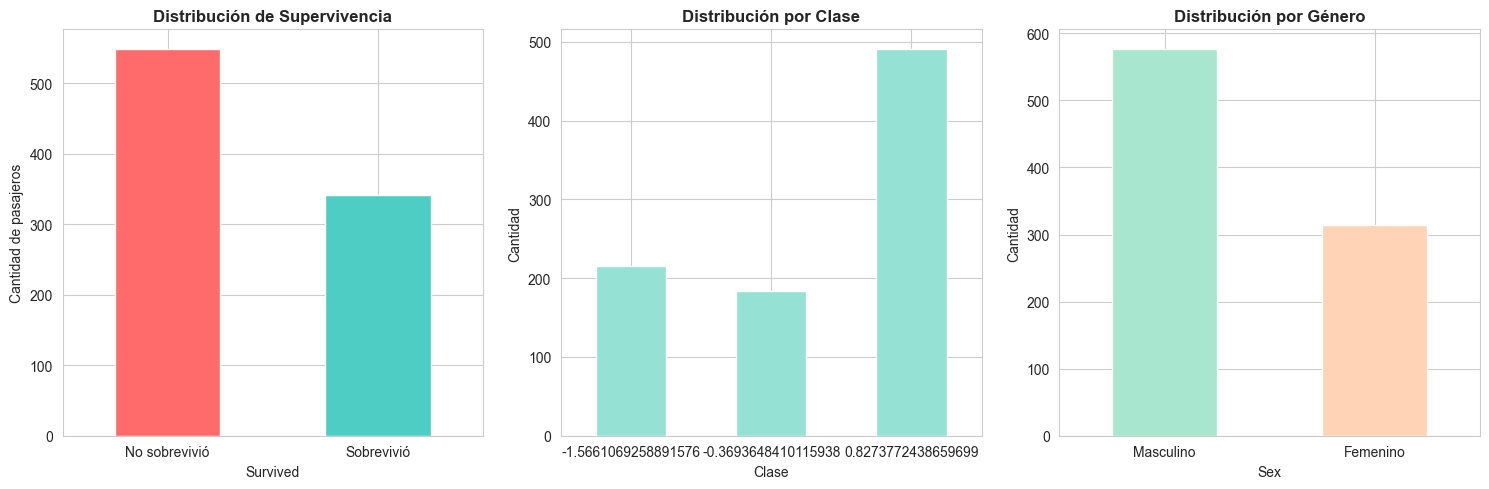


📊 Matriz de correlación:


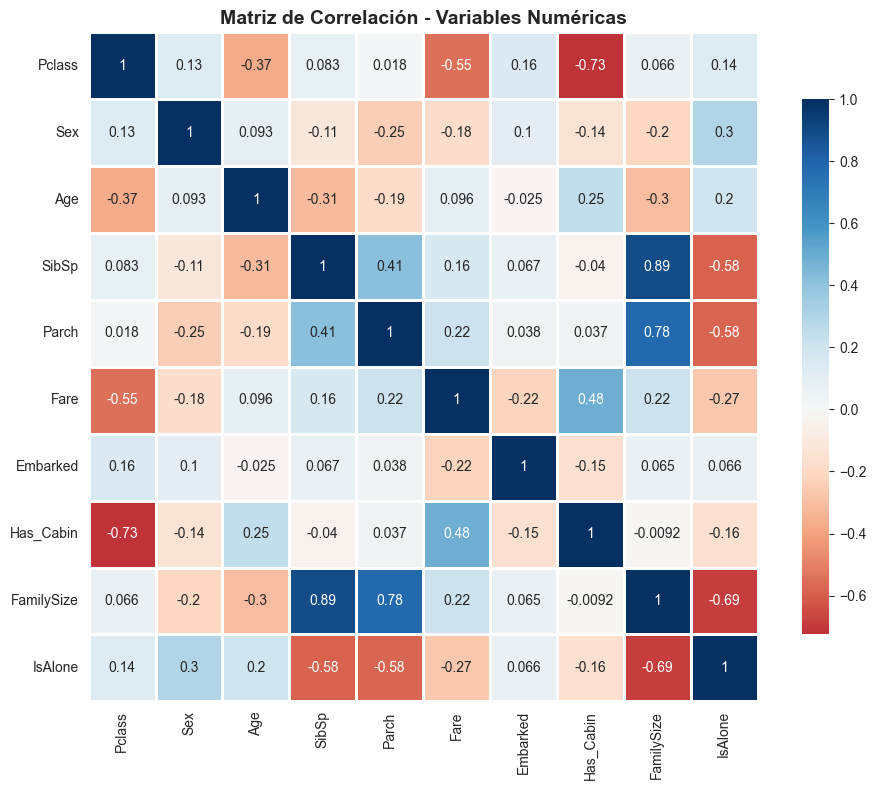


✅ ANÁLISIS COMPLETADO


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

print("="*50)
print("📊 ANÁLISIS EXPLORATORIO - DATOS TITANIC")
print("="*50)

# 1. Verificar dónde estamos parados
directorio_actual = os.getcwd()
print(f"\n📂 Directorio actual: {directorio_actual}")
print(f"📁 Estamos en carpeta: {os.path.basename(directorio_actual)}")

# 2. Construir ruta correcta para datos
# Como estamos en notebooks/, los datos están en ../data/processed/
ruta_base = Path.cwd().parent / 'data' / 'processed'
print(f"🔍 Buscando datos en: {ruta_base}")

# 3. Verificar que la carpeta existe
if not ruta_base.exists():
    print(f"\n❌ ERROR: No se encuentra la carpeta: {ruta_base}")
    print("\n🔧 Posibles soluciones:")
    print("   1. Ejecuta primero src/data_preparation.py")
    print("   2. Verifica que los archivos existen con:")
    print("      !dir ..\\data\\processed")
    print("   3. O usa la ruta absoluta:")
    print('      X_train = pd.read_csv("C:/Alex/Maestria/MLOPs/Final28022026/mlops-final-project-aor/data/processed/X_train.csv")')
else:
    # 4. Listar archivos encontrados
    archivos = list(ruta_base.glob("*.csv"))
    print(f"\n📋 Archivos encontrados en processed:")
    for archivo in archivos:
        print(f"   - {archivo.name}")
    
    # 5. Cargar datos con verificación
    try:
        X_train = pd.read_csv(ruta_base / 'X_train.csv')
        y_train = pd.read_csv(ruta_base / 'y_train.csv')
        
        print("\n" + "="*50)
        print("✅ DATOS CARGADOS EXITOSAMENTE")
        print("="*50)
        
        print(f"\n📊 Dimensiones:")
        print(f"   X_train: {X_train.shape}")
        print(f"   y_train: {y_train.shape}")
        
        print("\n📋 Primeras 5 filas de X_train:")
        print(X_train.head())
        
        print("\n📋 Primeras 5 filas de y_train:")
        print(y_train.head())
        
        print("\n📊 Información de X_train:")
        print(X_train.info())
        
        print("\n📊 Estadísticas descriptivas:")
        print(X_train.describe())
        
        # 6. Análisis de variable objetivo
        print("\n📊 Distribución de supervivencia:")
        surv_counts = y_train['Survived'].value_counts()
        surv_pct = y_train['Survived'].value_counts(normalize=True) * 100
        
        for valor in [0, 1]:
            label = "No sobrevivió" if valor == 0 else "Sobrevivió"
            count = surv_counts.get(valor, 0)
            pct = surv_pct.get(valor, 0)
            print(f"   {label}: {count} personas ({pct:.1f}%)")
        
        # 7. Visualizaciones básicas
        print("\n📊 Generando visualizaciones...")
        
        # Configurar estilo
        sns.set_style("whitegrid")
        
        # Figura 1: Distribución de supervivencia
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        y_train['Survived'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
        plt.title('Distribución de Supervivencia', fontsize=12, fontweight='bold')
        plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'], rotation=0)
        plt.ylabel('Cantidad de pasajeros')
        
        # Figura 2: Distribución por clase (si existe)
        plt.subplot(1, 3, 2)
        if 'Pclass' in X_train.columns:
            X_train['Pclass'].value_counts().sort_index().plot(kind='bar', color='#95E1D3')
            plt.title('Distribución por Clase', fontsize=12, fontweight='bold')
            plt.xlabel('Clase')
            plt.ylabel('Cantidad')
            plt.xticks(rotation=0)
        
        # Figura 3: Distribución por género (si existe)
        plt.subplot(1, 3, 3)
        if 'Sex' in X_train.columns:
            X_train['Sex'].value_counts().plot(kind='bar', color=['#A8E6CF', '#FFD3B6'])
            plt.title('Distribución por Género', fontsize=12, fontweight='bold')
            plt.xticks([0, 1], ['Masculino', 'Femenino'], rotation=0)
            plt.ylabel('Cantidad')
        
        plt.tight_layout()
        plt.show()
        
        # 8. Matriz de correlación
        print("\n📊 Matriz de correlación:")
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            plt.figure(figsize=(10, 8))
            correlation = X_train[numeric_cols].corr()
            sns.heatmap(correlation, annot=True, cmap='RdBu', center=0, 
                        square=True, linewidths=1, cbar_kws={"shrink": 0.8})
            plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        
        print("\n" + "="*50)
        print("✅ ANÁLISIS COMPLETADO")
        print("="*50)
        
    except FileNotFoundError as e:
        print(f"\n❌ ERROR: No se pudo cargar un archivo: {e}")
        print("\n🔧 Verifica que los archivos existen con:")
        print("   !dir ..\\data\\processed")
        
    except Exception as e:
        print(f"\n❌ ERROR inesperado: {e}")